In [ ]:
# 라이브러리 설치

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.5/913.5 kB 25.5 MB/s eta 0:00:00


In [ ]:
import torch
torch.cuda.is_available()

True

# Training Process

1. Data 형식

input: image -> output: grid and label


2. Train and Validation

Train만 시키는 경우 train에서 본 것만 잘 맞추는, 혹은 실제 데이터를 보고도, train에서 본거라고만 말함.

예시: Zebra 학습만 할 경우, giraffe elephant 등등을 보고도 그냥 zebra라고 할 수 있음.

Validation으로 그래서 overfitting을 방지한다.

In [ ]:
from ultralytics import YOLO

# Load A model

model = YOLO("yolo11n.pt")

# Train the model
train_results = model.train(
    data="coco8.yaml", # path to dataset YAML
    epochs=100,
    imgsz=640,
    device=0 # first gpu, # device=0,1,2,3 or device=cpu
)

# Evaluate Model performance on the validation set
metrics = model.val()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 115MB/s]


Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=coco8.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=

100%|██████████| 433k/433k [00:00<00:00, 15.9MB/s]
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100%|██████████| 25/25 [00:00<00:00, 3836.02file/s]

Dataset download success ✅ (0.9s), saved to /content/datasets



...


100 epochs completed in 0.031 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 20.14it/s]


                   all          4         17      0.597      0.867      0.895      0.652
                person          3         10      0.625        0.7      0.644      0.321
                   dog          1          1      0.523          1      0.995      0.796
                 horse          1          2      0.594          1      0.995      0.676
              elephant          1          2      0.371        0.5      0.745      0.325
              umbrella          1          1      0.549          1      0.995      0.895
          potted plant          1          1      0.921          1      0.995      0.895
Speed: 0.2ms preprocess, 5.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train
Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs


val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.60it/s]


                   all          4         17      0.597      0.867      0.895      0.652
                person          3         10      0.626        0.7      0.644      0.321
                   dog          1          1      0.523          1      0.995      0.796
                 horse          1          2      0.593          1      0.995      0.676
              elephant          1          2      0.372        0.5      0.745      0.325
              umbrella          1          1      0.549          1      0.995      0.895
          potted plant          1          1      0.916          1      0.995      0.895
Speed: 0.4ms preprocess, 42.9ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/train2



image 1/1 /content/TEST/test_image_2.webp: 640x640 2 dogs, 3 chairs, 2 potted plants, 1 vase, 8.6ms
Speed: 3.3ms preprocess, 8.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


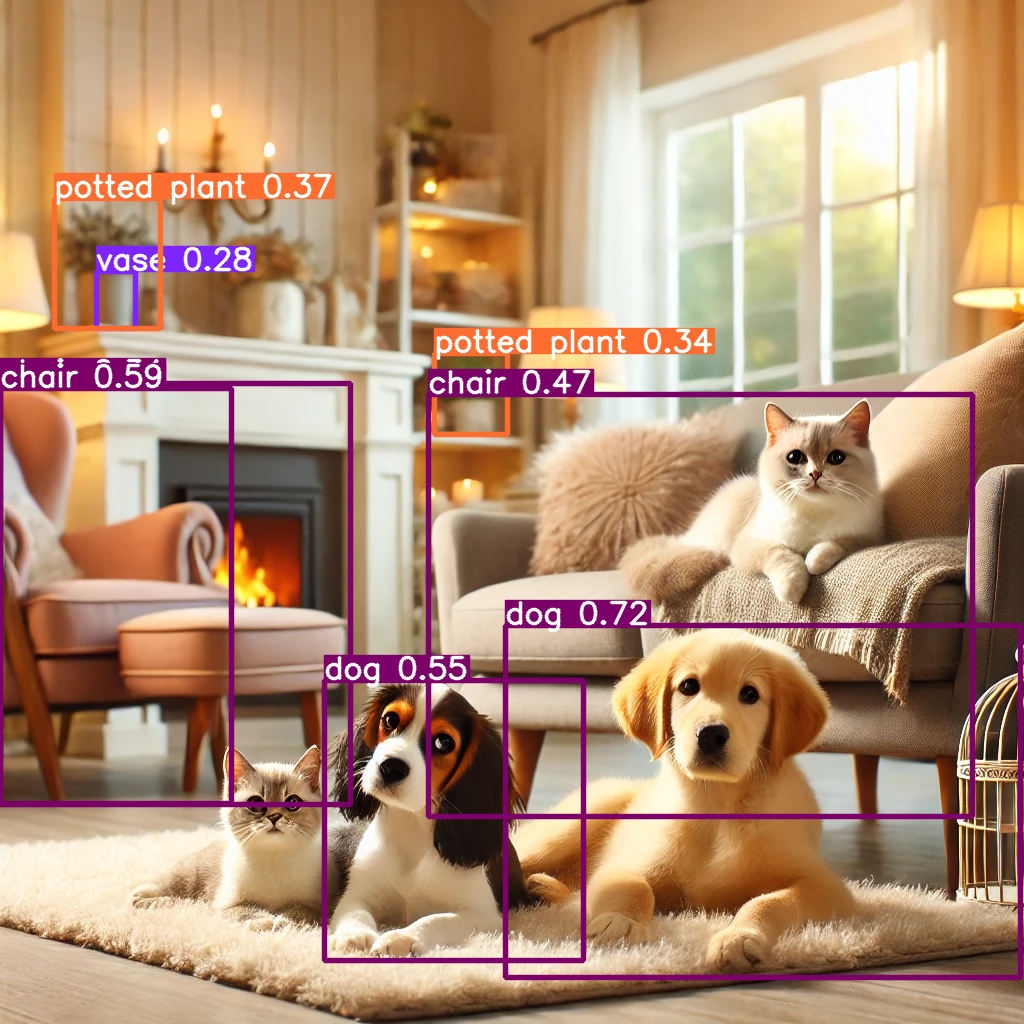

Ultralytics 8.3.67 🚀 Python-3.11.11 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.48...
ONNX: export success ✅ 1.3s, saved as 'runs/detect/train/weights/best.onnx' (10.2 MB)

Export complete (1.7s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=640 data=/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/datasets/coco8.yaml  
Visualize:       https://netron.app


In [ ]:
# Perform object detection on an image
results = model("/content/TEST/test_image_2.webp")
results[0].show()

# Export the model to ONNX format
path = model.export(format="onnx") # return path to exported model